In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast
import random
from tqdm import tqdm
import numpy as np

# Part 1: Mixing Patterns and Assortativity

## Part 1: Assortativity Coefficient

Calculate the Assortativity Coefficient for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in this paper (equation 2, here for directed networks). Do not use the NetworkX implementation.

### Creating the network

In [34]:
df = pd.read_csv('./D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)
df

,id,publication_year,cited_by_count,author_ids,title,abstract_inverted_index
0,https://openalex.org/W2095655043,2013,3006,"[https://openalex.org/A5090665793, https://ope...",Text as Data: The Promise and Pitfalls of Auto...,"{'Politics': [0], 'and': [1, 9, 67, 96, 99, 10..."
1,https://openalex.org/W2147453867,2006,2126,"[https://openalex.org/A5058815871, https://ope...",Experimental Study of Inequality and Unpredict...,"{'Hit': [0], 'songs,': [1], 'books,': [2], 'an..."
2,https://openalex.org/W2150375325,2007,1866,"[https://openalex.org/A5000679279, https://ope...","Influentials, Networks, and Public Opinion For...","{'A': [0], 'central': [1], 'idea': [2], 'in': ..."
3,https://openalex.org/W2096974619,2014,1830,"[https://openalex.org/A5082742221, https://ope...",Structural Topic Models for Open‐Ended Survey ...,"{'Collection': [0], 'and': [1, 14, 37, 78, 97,..."
4,https://openalex.org/W2049607688,2006,1696,"[https://openalex.org/A5066696247, https://ope...",Empirical Analysis of an Evolving Social Network,"{'Social': [0], 'networks': [1], 'evolve': [2]..."
...,...,...,...,...,...,...
370,https://openalex.org/W1602696812,2008,12,"[https://openalex.org/A5079997412, https://ope...",Change Detection in Social Networks,"{'Abstract': [0], ':': [1], 'Social': [2], 'ne..."
371,https://openalex.org/W3037966274,2020,12,"[https://openalex.org/A5077142904, https://ope...",A Dataset of Fact-Checked Images Shared on Wha...,"{'(Dataset': [0], 'paper).': [1], 'In': [2, 59..."
372,https://openalex.org/W4287773562,2020,12,"[https://openalex.org/A5050370761, https://ope...",Stance in Replies and Quotes (SRQ): A New Data...,"{'Automated': [0], 'ways': [1], 'to': [2, 16, ..."
373,https://openalex.org/W431568915,2015,12,"[https://openalex.org/A5086827245, https://ope...",Dissecting the Spirit of Gezi: Influence vs. S...,NaN


### Creating the graph

In [35]:
G = nx.Graph() # Create an empty graph

pair_counts = defaultdict(int)


for author_list in df['author_ids']: # Iterate through each paper's author list
    for i in range(len(author_list)): # Iterate through each author in the list
        for j in range(i + 1, len(author_list)): # Iterate through pairs of authors
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()])) # Create a sorted tuple of unique author pairs
            pair_counts[pair] += 1 # Increment the count for this pair

# Convert the pair counts into a list of weighted edges for the graph
weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]

# Create weighted edges in the graph
G.add_weighted_edges_from(weighted_edgelist) # Adds edges with weights in the metadata of the graph, also creates nodes
weights = [G[u][v]['weight'] for u, v in G.edges()] # Extract the weights for visualization

### Add attributes to nodes

In [36]:
for node in G.nodes():
    nx.set_node_attributes(G, {node: G.degree(node, weight='weight')}, 'degree') # change to correct information

### Solve the excercise

In [37]:
# Calculate the Assortativity Coefficient 
# Build degree dict from edge list
degree = defaultdict(int)
for (a, b), count in pair_counts.items():
    degree[a] += count
    degree[b] += count

edges = list(pair_counts.keys())
M = len(edges)

# Compute the three sums over all edges
sum_jk   = sum(degree[a] * degree[b] for a, b in edges)
sum_half = sum((degree[a] + degree[b]) / 2 for a, b in edges)
sum_sq   = sum((degree[a]**2 + degree[b]**2) / 2 for a, b in edges)

r = (M * sum_jk - sum_half**2) / (M * sum_sq - sum_half**2)

print(f"Assortativity coefficient: {r:.4f}")
print("Which means that the network is disassortive, meaning authors with many co-authors")
print("tend to collaborate with authors who have fewer co-authors, and vice versa.")

Assortativity coefficient: -0.1741
Which means that the network is disassortive, meaning authors with many co-authors
tend to collaborate with authors who have fewer co-authors, and vice versa.


## Part 2: Configuration model

In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.

Implement the configuration model using the double edge swap algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:

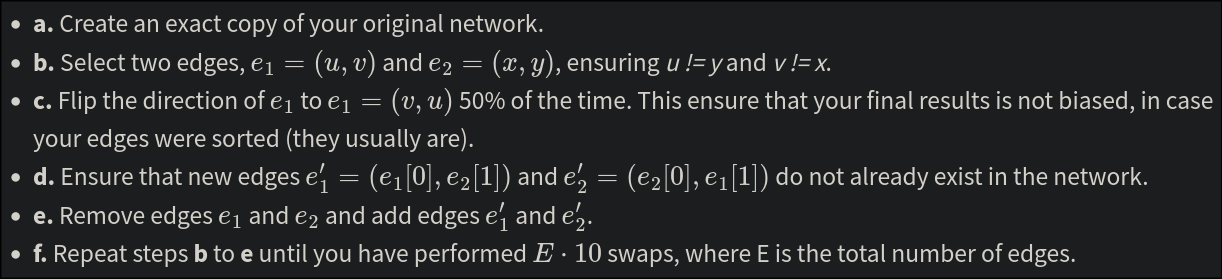

In [38]:
def configuration_mode_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0

    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        u, v = e1
        x, y = e2

        # c. Flip e1 50% of the time
        if random.random() < 0.5:
            u, v = v, u

        # b. Ensure u != y and v != x (spec requirement)
        if u == y or v == x:
            continue

        # New edges would be e1' = (u, y) and e2' = (x, v)
        # d. Ensure new edges don't already exist in the network
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            # e. Remove old edges, add new ones
            G_copy.remove_edge(*e1)
            G_copy.remove_edge(*e2)
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)

            edges.remove(e1)
            edges.remove(e2)
            edges.append((u, y))
            edges.append((x, v))

            swaps_done += 1

    return G_copy

Double check that your algorithm works well, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.

In [39]:
original_degrees = dict(G.degree())
G_rand = configuration_mode_swap(G)
rand_degrees = dict(G_rand.degree())
assert original_degrees == rand_degrees, "Degrees don't match!"
print("Degree check passed")

Degree check passed


## Part 3: Analyzing Assortativity in Random Networks

Generate and analyze at least 100 random networks using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

In [40]:
# Each author node does not have a country attribute since data is pulled from the papers dataset, so
# we will assign then countries using the authors dataset

authors_df = pd.read_csv('./final_authors.csv')
country_map = dict(zip(authors_df['id'], authors_df['country_code'])) # Map ID to country code

for node in G.nodes():
    G.nodes[node]['country'] = country_map.get(node, None) # Assign country code to node attr., default to None if not found

# Verify
print(list(G.nodes(data=True))[:3])

[('https://openalex.org/A5090665793', {'degree': 17, 'country': 'US'}), ('https://openalex.org/A5113226689', {'degree': 58, 'country': 'US'}), ('https://openalex.org/A5040821463', {'degree': 15, 'country': 'US'})]


100%|██████████| 100/100 [00:34<00:00,  2.90it/s]


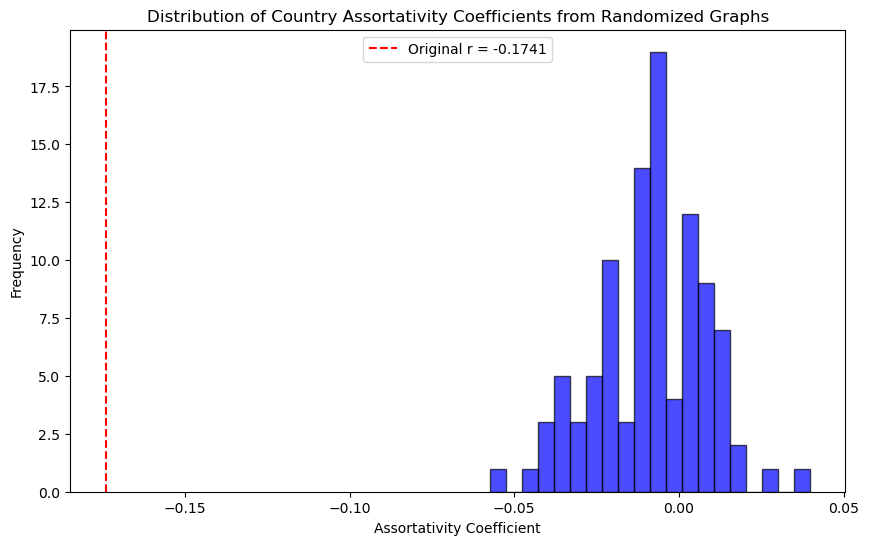

In [41]:
original_r = r

# Generate 100 randomized graphs and compute their assortativity coefficients
randomized_rs = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r = nx.attribute_assortativity_coefficient(G_rand, 'country')
    randomized_rs.append(r)

# Plot the distribution of randomized assortativity coefficients
plt.figure(figsize=(10, 6))
plt.hist(randomized_rs, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(original_r, color='red', linestyle='dashed', label=f'Original r = {original_r:.4f}')
plt.title('Distribution of Country Assortativity Coefficients from Randomized Graphs')
plt.xlabel('Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Part 4: Assortativity by Degree

Calculate degree assortativity for your network using the formula discussed in the lecture.

In [44]:
def degree_assortativity(G):
    edges = list(G.edges())
    ku = np.array([G.degree(u, weight='weight') for u, v in edges])
    kv = np.array([G.degree(v, weight='weight') for u, v in edges])

    numerator = np.mean(ku * kv) - np.mean(ku) * np.mean(kv)
    denominator = np.mean(ku**2) - np.mean(ku)**2
    return numerator / denominator if denominator != 0 else 0

r = degree_assortativity(G)
print(f"Degree assortativity coefficient: {r:.4f}")

Degree assortativity coefficient: -0.0140


Compare your network’s degree assortativity against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa.

100%|██████████| 100/100 [00:33<00:00,  2.98it/s]


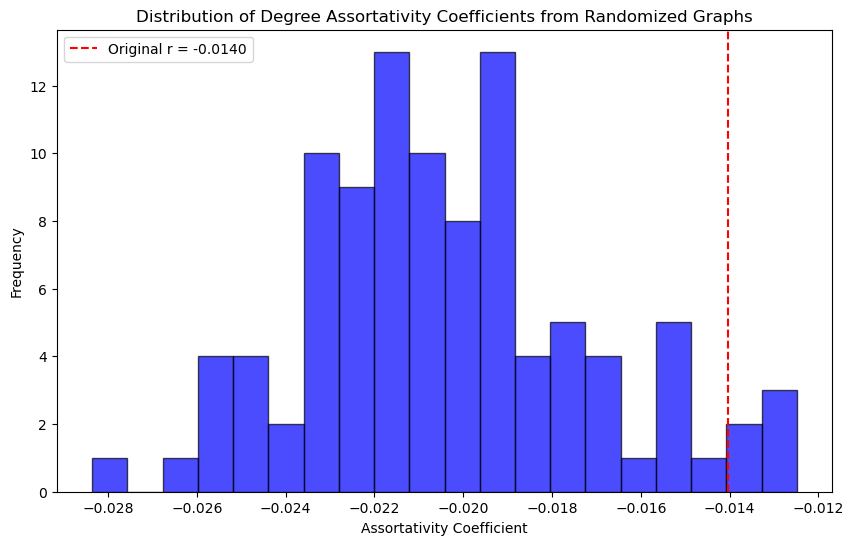

In [45]:
original_r = degree_assortativity(G)

# Generate 100 randomized graphs and compute their assortativity coefficients
randomized_rs = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r = degree_assortativity(G_rand)
    randomized_rs.append(r)

# Plot the distribution of randomized assortativity coefficients
plt.figure(figsize=(10, 6))
plt.hist(randomized_rs, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(original_r, color='red', linestyle='dashed', label=f'Original r = {original_r:.4f}')
plt.title('Distribution of Degree Assortativity Coefficients from Randomized Graphs')
plt.xlabel('Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Part 5: Reflection questions

### Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?

The results were not fully in line with expectations. The original network's degree assortativity (r = −0.0140) sits at the far right tail of the randomized distribution, which ranges roughly from −0.028 to −0.012. This means the original network is actually less disassortative than most of the random networks generated by the configuration model.
This is surprising for two reasons:

The randomized networks are more disassortative than the real one. Purely by preserving the degree sequence, the configuration model produces networks where hubs connect with low-degree nodes even more than in the real network. This suggests that in reality, high-degree authors have a slight tendency to connect with each other more than random chance would predict. A weak assortative pull that counteracts the structural disassortativity imposed by the degree distribution.
The result is statistically notable. Since the original r = −0.0140 sits at the edge of the null distribution, it suggests the real network's mixing pattern is not fully explained by its degree sequence alone, there may be a genuine (if weak) social mechanism driving high-degree authors toward each other, such as conference co-attendance, shared institutions, or prestige-based collaboration.

### Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing e_1 from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?

The flip is included to remove directional bias in how new edges are formed during the swap.
When you build the edge list with list(G.edges()), NetworkX returns edges in a consistent internal order, meaning for any edge (u, v), u will always appear as the first node and v as the second. This ordering is not random; it reflects the order nodes were added to the graph, which in your case is driven by how authors appear in the dataset (likely sorted or grouped in some systematic way).
Without the flip, the new edges created by the swap are always (u, y) and (x, v), meaning the "first" nodes of each original edge always stay as "first" nodes in the new edges. Over E×10 swaps, this creates a systematic bias where certain nodes are disproportionately likely to end up on one "side" of new connections, skewing the degree distribution of the randomized network.
By flipping e₁ from (u, v) to (v, u) 50% of the time, you randomize which end of the edge gets "mixed" with the other edge, ensuring that over many swaps the pairing is symmetric and unbiased.
In short: the flip ensures the randomization is truly random, not an artifact of however the edges happened to be ordered in memory. Without it, your null model would be subtly broken, and the 100 randomized networks wouldn't be genuinely exchangeable with the original.

### Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.

The distribution of degree assortativity values across the 100 randomized networks is roughly bell-shaped and centered around −0.020, ranging from approximately −0.028 to −0.013. It is slightly right-skewed, with the bulk of values concentrated between −0.023 and −0.019.
Was this expected?
Yes and no. It is expected that the distribution clusters tightly around a negative value. This is a well-known property of networks with heterogeneous degree distributions (i.e. where some nodes have vastly higher degree than others, as is typical in co-authorship networks). In such networks, the configuration model structurally produces disassortativity almost by definition: there simply aren't enough high-degree nodes for hubs to consistently connect with other hubs, so they end up connecting with low-degree nodes more often than not.
The tight spread of the distribution is also expected and is a direct consequence of how the configuration model works. Because every randomized network preserves the exact same degree sequence as the original, all 100 networks share the same fundamental structural constraint. The edge flipping ensures these networks are genuinely randomized rather than biased copies, so the variance we do see reflects only the stochasticity of the swap process, not differences in degree structure. This is why the distribution is narrow: you're sampling from a well-defined null model, not from arbitrary random graphs.
What the distribution tells us theoretically
The configuration model's null distribution represents what assortativity should look like if connections were made purely at random given the degree sequence, no social preferences, no homophily, no institutional effects. The fact that the distribution is entirely negative confirms that disassortativity in this type of network is a structural inevitability, not a behavioural signal. Any real network built on a similar degree sequence would be expected to land somewhere in this range purely by chance.
The original network's value (−0.0140) sitting at the right tail of this distribution is therefore the meaningful finding. It suggests the real collaboration network is less disassortative than pure randomness would predict, hinting at weak but genuine assortative social forces at play beyond what the degree sequence alone can explain.